In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

base   = r'C:\Users\chant\ecommerce-analytics\data\raw'
out    = r'C:\Users\chant\ecommerce-analytics\data\processed'
models = r'C:\Users\chant\ecommerce-analytics\models'

products = pd.read_csv(os.path.join(base, 'products.csv'))
orders   = pd.read_csv(os.path.join(base, 'orders.csv'), parse_dates=['order_date'])
returns  = pd.read_csv(os.path.join(base, 'returns.csv'))
print("Loaded")

Loaded


In [2]:
# seller-level aggregation
seller_stats = products.groupby('seller_id').agg(
    total_products     = ('product_id', 'count'),
    fake_product_rate  = ('is_authentic', lambda x: (x == False).mean()),
    avg_price          = ('price', 'mean'),
    price_std          = ('price', 'std')
).reset_index()

# merge return complaints per seller
orders_prod = orders.merge(products[['product_id','seller_id']], on='product_id', how='left')
returns_merged = returns.merge(orders_prod[['order_id','seller_id']], on='order_id', how='left')

counterfeit_returns = (returns_merged[returns_merged['reason']=='counterfeit suspected']
                       .groupby('seller_id').size().reset_index(name='counterfeit_complaints'))
total_returns = returns_merged.groupby('seller_id').size().reset_index(name='total_returns')

seller_stats = seller_stats.merge(counterfeit_returns, on='seller_id', how='left')
seller_stats = seller_stats.merge(total_returns,       on='seller_id', how='left')
seller_stats = seller_stats.fillna(0)
seller_stats['complaint_rate'] = seller_stats['counterfeit_complaints'] / (seller_stats['total_products'] + 1)
seller_stats['price_std']      = seller_stats['price_std'].fillna(0)

print(f"Seller profiles built: {seller_stats.shape}")
print(seller_stats.describe().round(2))

Seller profiles built: (50, 8)
       total_products  fake_product_rate  avg_price  price_std  \
count           50.00              50.00      50.00      50.00   
mean            10.00               0.13     858.83     677.97   
std              2.86               0.13     275.53     328.22   
min              3.00               0.00     371.58     179.92   
25%              8.25               0.00     673.02     449.92   
50%             10.00               0.10     802.48     633.06   
75%             11.75               0.17    1024.06     880.70   
max             17.00               0.57    1471.45    1621.43   

       counterfeit_complaints  total_returns  complaint_rate  
count                   50.00          50.00           50.00  
mean                     1.86          18.00            0.16  
std                      1.50           6.36            0.12  
min                      0.00           3.00            0.00  
25%                      1.00          14.00            0.0

In [3]:
features = ['total_products','fake_product_rate','avg_price',
            'price_std','counterfeit_complaints','complaint_rate']

X = seller_stats[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.12,
    random_state=42
)
iso.fit(X_scaled)

seller_stats['anomaly_score']  = -iso.score_samples(X_scaled)
seller_stats['is_suspicious']  = iso.predict(X_scaled) == -1
seller_stats['risk_tier'] = pd.cut(
    seller_stats['anomaly_score'],
    bins=3, labels=['Low Risk', 'Medium Risk', 'High Risk'])

print(f"\nSuspicious sellers flagged: {seller_stats['is_suspicious'].sum()}")
print(f"% of all sellers          : {seller_stats['is_suspicious'].mean()*100:.1f}%")
print(f"\nTop 10 riskiest sellers:")
print(seller_stats.nlargest(10,'anomaly_score')[
    ['seller_id','total_products','fake_product_rate',
     'counterfeit_complaints','anomaly_score','risk_tier']
].to_string(index=False))


Suspicious sellers flagged: 6
% of all sellers          : 12.0%

Top 10 riskiest sellers:
seller_id  total_products  fake_product_rate  counterfeit_complaints  anomaly_score   risk_tier
     S045              10           0.000000                     6.0       0.612724   High Risk
     S039               4           0.000000                     0.0       0.566739   High Risk
     S009              14           0.357143                     5.0       0.555943   High Risk
     S041               7           0.571429                     1.0       0.554754   High Risk
     S007              11           0.090909                     4.0       0.539987   High Risk
     S036               3           0.000000                     0.0       0.530115 Medium Risk
     S038              12           0.000000                     2.0       0.529730 Medium Risk
     S012               9           0.333333                     0.0       0.526913 Medium Risk
     S049               5           0.000000 

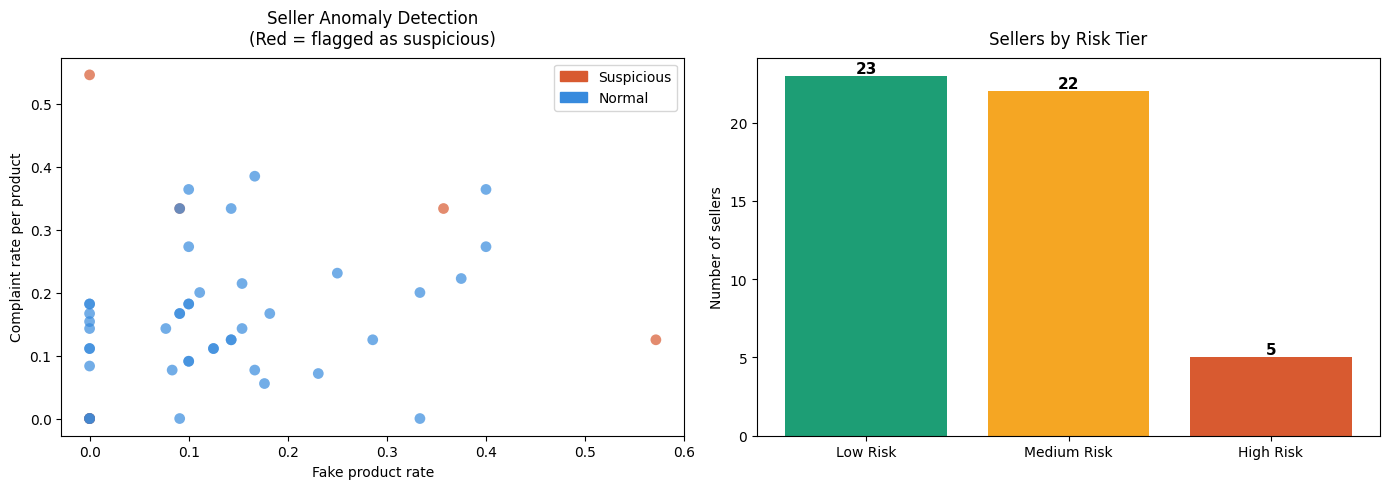

Model 3 saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatter: fake rate vs complaint rate, coloured by suspicion
colors = ['#D85A30' if s else '#378ADD' for s in seller_stats['is_suspicious']]
axes[0].scatter(seller_stats['fake_product_rate'],
                seller_stats['complaint_rate'],
                c=colors, alpha=0.7, s=60, edgecolors='none')
axes[0].set_title('Seller Anomaly Detection\n(Red = flagged as suspicious)',
                   fontsize=12, pad=10)
axes[0].set_xlabel('Fake product rate')
axes[0].set_ylabel('Complaint rate per product')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#D85A30', label='Suspicious'),
                          Patch(color='#378ADD', label='Normal')], fontsize=10)

# risk tier distribution
tier_counts = seller_stats['risk_tier'].value_counts().sort_index()
bar_colors  = ['#1D9E75','#F5A623','#D85A30']
axes[1].bar(tier_counts.index.astype(str), tier_counts.values,
            color=bar_colors, edgecolor='none')
axes[1].set_title('Sellers by Risk Tier', fontsize=12, pad=10)
axes[1].set_ylabel('Number of sellers')
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(out, 'model3_seller_anomaly.png'), dpi=150)
plt.show()

joblib.dump(iso,    os.path.join(models, 'anomaly_model.pkl'))
joblib.dump(scaler, os.path.join(models, 'anomaly_scaler.pkl'))
seller_stats.to_csv(os.path.join(out, 'seller_risk_scores.csv'), index=False)
print("Model 3 saved")